# **Day 27: Logistic Regression**
*Module 5 - Classification*

Despite its name, logistic regression is a **classification** model. It outputs **probabilities**, has interpretable coefficients (odds ratios), trains fast, and is the standard baseline in medicine, social science, credit scoring and remote sensing.

> Logistic regression predicts the probability of a yes/no outcome. It computes a weighted sum of the inputs and squeezes it between 0 and 1 with the sigmoid curve. It is simple, fast and easy to interpret.
>
> *Example:* From NDWI and slope, logistic regression might say a pixel has an 85% probability of being flooded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit, softmax
rng = np.random.default_rng(27)

## **1. From Score to Probability**
A linear model gives a score $z = \mathbf w^\top\mathbf x + b \in (-\infty, \infty)$. The **sigmoid** squashes it into a probability:
$$P(y=1\mid\mathbf x) = \sigma(z) = \frac{1}{1+e^{-z}}$$
Inverting: $\log\frac{p}{1-p} = \mathbf w^\top\mathbf x + b$. The model is **linear in the log-odds**.

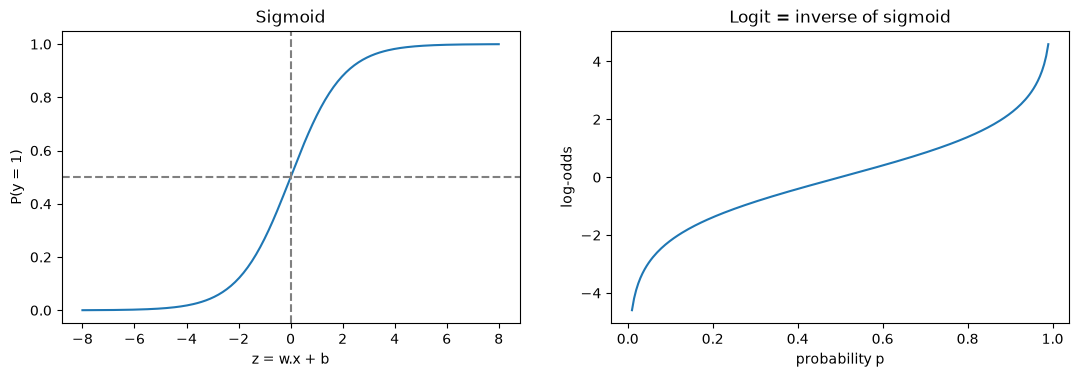

In [2]:
z = np.linspace(-8, 8, 200)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(z, expit(z)); axes[0].axhline(0.5, ls="--", c="grey"); axes[0].axvline(0, ls="--", c="grey")
axes[0].set(xlabel="z = w.x + b", ylabel="P(y = 1)", title="Sigmoid")
p = np.linspace(0.01, 0.99, 200)
axes[1].plot(p, np.log(p / (1 - p))); axes[1].set(xlabel="probability p", ylabel="log-odds", title="Logit = inverse of sigmoid")
plt.show()

## **2. A First Model and Odds Ratios**
Example: probability that a hillslope cell failed (landslide) as a function of slope angle and distance to a road.

In [3]:
n = 1500
slope = rng.uniform(0, 45, n); road_dist = rng.exponential(400, n)
logit_true = -6 + 0.15 * slope - 0.003 * road_dist
fail = (rng.random(n) < expit(logit_true)).astype(int)
df = pd.DataFrame({"slope": slope, "road_dist": road_dist, "landslide": fail})
print("Landslide rate:", df.landslide.mean().round(3))

import statsmodels.formula.api as smf
lg = smf.logit("landslide ~ slope + road_dist", data=df).fit(disp=0)
print(lg.summary().tables[1])
odds = pd.DataFrame({"odds_ratio": np.exp(lg.params), "CI_low": np.exp(lg.conf_int()[0]), "CI_high": np.exp(lg.conf_int()[1])})
print(odds.round(4))

Landslide rate: 0.087


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.4508      0.466    -11.704      0.000      -6.364      -4.538
slope          0.1357      0.013     10.481      0.000       0.110       0.161
road_dist     -0.0036      0.001     -6.851      0.000      -0.005      -0.003
           odds_ratio  CI_low  CI_high
Intercept      0.0043  0.0017   0.0107
slope          1.1454  1.1167   1.1748
road_dist      0.9964  0.9954   0.9974


**Interpretation:** each extra degree of slope multiplies the **odds** of failure by $e^{0.15}\approx1.16$ (+16%). 10 degrees: $1.16^{10}\approx 4.5$ times the odds. Each 100 m further from a road multiplies the odds by $e^{-0.3}\approx 0.74$.

## **3. Training: Maximum Likelihood = Cross-Entropy**
$$\mathcal L(\mathbf w) = -\frac1n\sum_i\big[y_i\log p_i + (1-y_i)\log(1-p_i)\big],\qquad \nabla_{\mathbf w}\mathcal L = \frac1n X^\top(\mathbf p - \mathbf y)$$
The loss is **convex**: gradient descent finds the global optimum. Let us implement it.

In [4]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iter=5000, l2=0.0):
        self.lr, self.n_iter, self.l2 = lr, n_iter, l2
    def fit(self, X, y):
        n_, p_ = X.shape; self.w_ = np.zeros(p_); self.b_ = 0.0; self.losses_ = []
        for _ in range(self.n_iter):
            pr = expit(X @ self.w_ + self.b_)
            self.w_ -= self.lr * (X.T @ (pr - y) / n_ + self.l2 * self.w_)
            self.b_ -= self.lr * np.mean(pr - y)
            self.losses_.append(-np.mean(y * np.log(pr + 1e-12) + (1 - y) * np.log(1 - pr + 1e-12)))
        return self
    def predict_proba(self, X):
        return expit(X @ self.w_ + self.b_)
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(df[["slope", "road_dist"]])
scratch = LogisticRegressionScratch(lr=0.5, n_iter=3000).fit(Xs, df.landslide.values)
from sklearn.linear_model import LogisticRegression
sk = LogisticRegression(C=np.inf).fit(Xs, df.landslide)
print("scratch:", scratch.w_.round(4), round(scratch.b_, 4))
print("sklearn:", sk.coef_[0].round(4), sk.intercept_.round(4))

scratch: [ 1.78   -1.4074] -3.8203
sklearn: [ 1.7798 -1.4082] [-3.8205]


## **4. Decision Boundary and Regularisation**
The boundary $P=0.5$ is where $\mathbf w^\top\mathbf x + b = 0$: a **straight line** (hyperplane). Non-linear boundaries need engineered features (polynomials, splines) or other models.

In scikit-learn, **C is the inverse of the regularisation strength** ($C = 1/\lambda$): small C = strong regularisation. `l1_ratio=0` gives the L2 (Ridge) penalty (default); `l1_ratio=1` gives L1 (Lasso, sparse) and needs `solver="saga"` or `"liblinear"`.

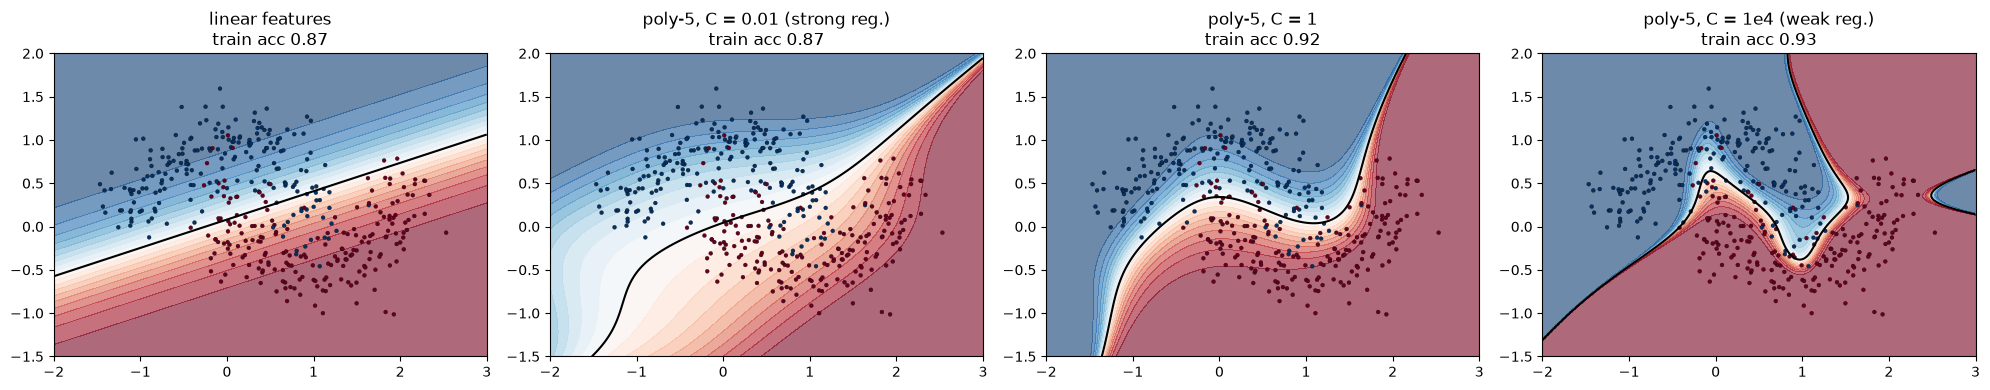

In [5]:
from sklearn.datasets import make_moons
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
Xm, ym = make_moons(400, noise=0.25, random_state=0)
xx, yy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300)); grid = np.c_[xx.ravel(), yy.ravel()]
configs = {"linear features": make_pipeline(StandardScaler(), LogisticRegression()),
           "poly-5, C = 0.01 (strong reg.)": make_pipeline(PolynomialFeatures(5), StandardScaler(), LogisticRegression(C=0.01, max_iter=5000)),
           "poly-5, C = 1": make_pipeline(PolynomialFeatures(5), StandardScaler(), LogisticRegression(C=1, max_iter=5000)),
           "poly-5, C = 1e4 (weak reg.)": make_pipeline(PolynomialFeatures(5), StandardScaler(), LogisticRegression(C=1e4, max_iter=20000))}
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, m) in zip(axes, configs.items()):
    m.fit(Xm, ym); P = m.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, P, levels=20, cmap="RdBu_r", alpha=0.6); ax.contour(xx, yy, P, levels=[0.5], colors="k")
    ax.scatter(*Xm.T, c=ym, cmap="RdBu_r", s=8, edgecolor="k", lw=0.2); ax.set_title(f"{name}\ntrain acc {m.score(Xm, ym):.2f}")
plt.tight_layout(); plt.show()

## **5. Multinomial (Softmax) Logistic Regression**
For $K$ classes, each class gets its own weight vector; probabilities come from the **softmax**:
$$P(y=k\mid\mathbf x) = \frac{e^{\mathbf w_k^\top\mathbf x}}{\sum_j e^{\mathbf w_j^\top\mathbf x}}$$
scikit-learn uses the multinomial loss by default for multi-class problems.

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
Xi, yi = load_iris(return_X_y=True)
mlr = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xi, yi)
print("CV accuracy:", cross_val_score(mlr, Xi, yi, cv=5).mean().round(3))
print("Coefficient matrix shape (classes x features):", mlr[-1].coef_.shape)
x0 = StandardScaler().fit(Xi).transform(Xi[:1])
scores = mlr[-1].coef_ @ x0.ravel() + mlr[-1].intercept_
print("softmax of scores:", softmax(scores).round(4), "| predict_proba:", mlr.predict_proba(Xi[:1]).round(4))

CV accuracy: 0.96
Coefficient matrix shape (classes x features): (3, 4)
softmax of scores: [0.9847 0.0153 0.    ] | predict_proba: [[0.9847 0.0153 0.    ]]


## **6. L1 Logistic Regression for Feature Selection**

In [7]:
from sklearn.datasets import load_breast_cancer
Xb, yb = load_breast_cancer(return_X_y=True, as_frame=True)
for C in [0.01, 0.05, 0.2, 1.0]:
    m = make_pipeline(StandardScaler(), LogisticRegression(l1_ratio=1, solver="saga", C=C, max_iter=10000))
    acc = cross_val_score(m, Xb, yb, cv=5).mean(); m.fit(Xb, yb)
    print(f"C = {C:<5} non-zero coefficients: {np.sum(m[-1].coef_ != 0):>2} of 30 | CV accuracy {acc:.3f}")

C = 0.01  non-zero coefficients:  3 of 30 | CV accuracy 0.875


C = 0.05  non-zero coefficients:  5 of 30 | CV accuracy 0.961


C = 0.2   non-zero coefficients: 10 of 30 | CV accuracy 0.972


C = 1.0   non-zero coefficients: 16 of 30 | CV accuracy 0.970


# **Part 2: Going Deeper - Perfect Separation**

If a feature (or combination) separates the classes **perfectly**, the likelihood keeps increasing as $\lVert\mathbf w\rVert\to\infty$: the MLE does not exist. statsmodels warns, coefficients explode, standard errors become meaningless, and probabilities become 0/1 (overconfident). This happens with small samples, rare classes and many features. **Regularisation** (or Firth's penalised likelihood) gives finite, sensible estimates.

In [8]:
xs_sep = np.r_[rng.uniform(0, 4, 20), rng.uniform(5, 9, 20)]; ys_sep = np.r_[np.zeros(20), np.ones(20)]
for C in [1e8, 100, 1]:
    m = LogisticRegression(C=C, max_iter=100000).fit(xs_sep[:, None], ys_sep)
    p_gap = m.predict_proba([[4.1], [4.5], [4.9]])[:, 1]
    print(f"C = {C:<8g} slope = {m.coef_[0, 0]:8.2f} | P(y=1) at x = 4.1 / 4.5 / 4.9 (inside the empty gap): {np.round(p_gap, 3)}")

C = 1e+08    slope =     9.42 | P(y=1) at x = 4.1 / 4.5 / 4.9 (inside the empty gap): [0.021 0.48  0.976]
C = 100      slope =     5.51 | P(y=1) at x = 4.1 / 4.5 / 4.9 (inside the empty gap): [0.076 0.426 0.87 ]
C = 1        slope =     1.75 | P(y=1) at x = 4.1 / 4.5 / 4.9 (inside the empty gap): [0.323 0.49  0.659]


With almost no regularisation, the slope is huge (and keeps growing with more iterations): the probability jumps from ~0 to ~1 **inside the empty gap**, where the model has never seen data. With regularisation the probability changes gradually across the gap, an honest expression of uncertainty.

### Logistic regression as a one-layer neural network
$\sigma(\mathbf w^\top\mathbf x + b)$ is exactly one neuron with a sigmoid activation and cross-entropy loss. Day 58 stacks many of them.

## **Practice Problems**
1. In the landslide model, what slope gives a 50% failure probability at road_dist = 200 m? (Solve $\mathbf w^\top\mathbf x + b = 0$.)
2. Add an interaction `slope:road_dist` to the statsmodels model. Is it significant?
3. Train `LogisticRegressionScratch` with `l2=0.1` and compare coefficients with `LogisticRegression(C=...)`. What C corresponds to l2 = 0.1? (Hint: sklearn minimises $\frac12\lVert w\rVert^2 + C\sum\text{loss}_i$.)
4. *(Advanced)* Plot calibration: bin predicted probabilities of the landslide model into deciles and compare with observed rates.

slope at P=0.5: 45.4 degrees
Intercept          0.000
slope              0.000
road_dist          0.457
slope:road_dist    0.405
dtype: float64


scratch: [ 0.5199 -0.2944] | sklearn: [ 0.52   -0.2941]


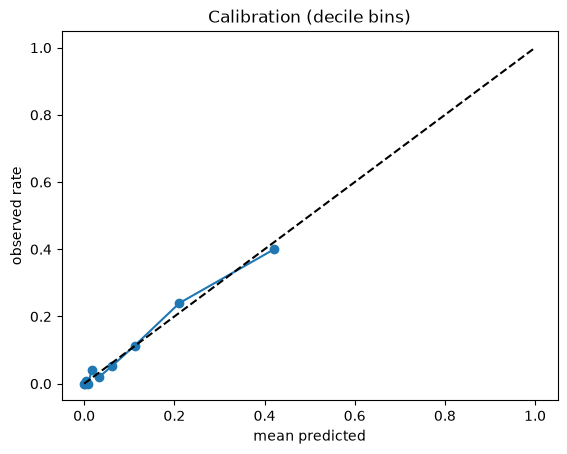

In [9]:
# Solution 1
b0, b_slope, b_road = lg.params
print(f"slope at P=0.5: {-(b0 + b_road * 200) / b_slope:.1f} degrees")
# Solution 2
print(smf.logit("landslide ~ slope * road_dist", data=df).fit(disp=0).pvalues.round(3))
# Solution 3: sklearn objective / n  ->  (1/(2Cn))||w||^2 + mean loss;  l2/2 ||w||^2  <->  C = 1/(l2 * n)
s2 = LogisticRegressionScratch(lr=0.5, n_iter=5000, l2=0.1).fit(Xs, df.landslide.values)
k2 = LogisticRegression(C=1 / (0.1 * n)).fit(Xs, df.landslide)
print("scratch:", s2.w_.round(4), "| sklearn:", k2.coef_[0].round(4))
# Solution 4
pp = lg.predict(df); bins = pd.qcut(pp, 10, duplicates="drop")
cal = pd.DataFrame({"p": pp, "y": df.landslide}).groupby(bins, observed=True).mean()
plt.plot(cal.p, cal.y, "o-"); plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("mean predicted"); plt.ylabel("observed rate"); plt.title("Calibration (decile bins)"); plt.show()

## **Key References**
- Cox, D. R. (1958). The regression analysis of binary sequences. *Journal of the Royal Statistical Society B*, 20(2), 215-242.
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.
- Firth, D. (1993). Bias reduction of maximum likelihood estimates. *Biometrika*, 80(1), 27-38.
- Ng, A. Y. (2004). Feature selection, L1 vs. L2 regularization, and rotational invariance. *ICML 2004*.
- Ayalew, L., & Yamagishi, H. (2005). The application of GIS-based logistic regression for landslide susceptibility mapping in the Kakuda-Yahiko Mountains, Central Japan. *Geomorphology*, 65(1-2), 15-31.